In [7]:
import numpy as np
import os
from glob import glob
from util.plotting import plot_3d_array_interactive
from RGTnet.models.net3d import model
from RGTnet.utils import get_parameter_number
from DNN.predict import predict_single_chunk
import matplotlib.pyplot as plt


In [8]:
param_model = {}
param_model['input_channels'] = 1
param_model['encoder_channels'] = 512      
param_model['decoder_channels'] = 16
mod = model(param_model)
get_parameter_number(mod)

{'Total': 56641012, 'Trainable': 56641012}

In [9]:
ind = 16
sl = (96, slice(None), slice(None))
sl2 = (1, slice(None), slice(None))
rgt_init = sorted(glob("/mnt/storage/nnseismic/synthetic_data/val/rgt/*"), key=lambda x: int(os.path.basename(x).split('.')[0]))
seis = sorted(glob("/mnt/storage/nnseismic/synthetic_data/val/seis/*"), key=lambda x: int(os.path.basename(x).split('.')[0]))
rgt = np.fromfile(rgt_init[ind], dtype=np.float32)
rgt = rgt.reshape((128, 128, 128))
seis_s = np.fromfile(seis[ind], dtype=np.float32)
seis_s = seis_s.reshape((128, 128, 128))

In [11]:
pred_rgt = predict_single_chunk(seis[ind], 
                                "/mnt/storage/nnseismic/runs/snet-1//checkpoints/best_model.pth",)

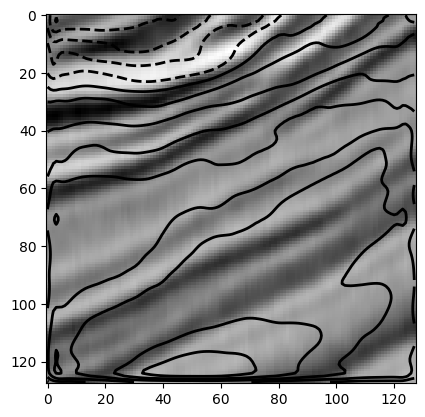

In [12]:
plt.imshow(seis_s[sl].T, cmap='grey', interpolation='nearest')
plt.contour(pred_rgt[sl].T,np.linspace(np.min(rgt),np.max(rgt),30),colors='black',linewidths=2)

In [54]:
cube = "/mnt/storage/nnseismic/synthetic_data/raw/labeled/seismicCubes_cumsum_fullstack_2026.27340332.npy"
testarr = np.load(cube)
plot_3d_array_interactive(testarr, axis='x', cmap='grey')

interactive(children=(IntSlider(value=0, description='X-index:', max=191), Output()), _dom_classes=('widget-in…

In [67]:


# print(seismic.size/1024/1024)
plot_3d_array_interactive(rgt, axis='x', cmap='jet')

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…

In [ ]:

# print(seismic.size/1024/1024)
plot_3d_array_interactive(seis_s, axis='x', cmap='grey')

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…

In [105]:
import pandas as pd
test = pd.read_csv("/mnt/storage/nnseismic/runs/exp2_Train/history/test_history.txt", sep=' |\t')
train = pd.read_csv("/mnt/storage/nnseismic/runs/exp2_Train/history/train_history.txt", sep=' |\t')

/tmp/ipykernel_32622/787564231.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  test = pd.read_csv("/mnt/storage/nnseismic/runs/exp2_Train/history/test_history.txt", sep=' |\t')
/tmp/ipykernel_32622/787564231.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  train = pd.read_csv("/mnt/storage/nnseismic/runs/exp2_Train/history/train_history.txt", sep=' |\t')


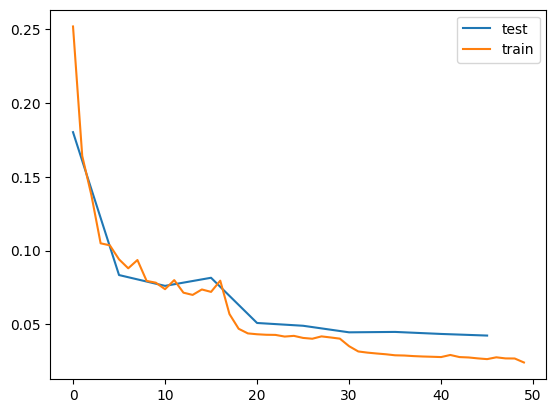

In [111]:
plt.plot(test.EPOCH, test.SSIM, label='test')
plt.plot(train.EPOCH, train.SSIM, label='train')
plt.legend()

In [16]:
seismic = np.fromfile("../data/0.dat", dtype=np.float32)
seismic = seismic.reshape((256, 256, 128))
plot_3d_array_interactive(seismic, axis='x', cmap='grey')

interactive(children=(IntSlider(value=0, description='X-index:', max=255), Output()), _dom_classes=('widget-in…

In [2]:
files = glob("../data/synthetic_data/run/seismic__2026.24239099_tagilst_test_5/*.npy")
for i in range(len(files)):
    print(f'{i} - {files[i]}')

In [3]:
cube = "../data/synthetic_data/run/seismic__2026.25220596_tagilsk_128_128_2000/faulted_age_2026.25220596.npy"
testarr = np.load(cube)
plot_3d_array_interactive(testarr, axis='x', cmap='prism')

interactive(children=(IntSlider(value=0, description='X-index:', max=127), Output()), _dom_classes=('widget-in…

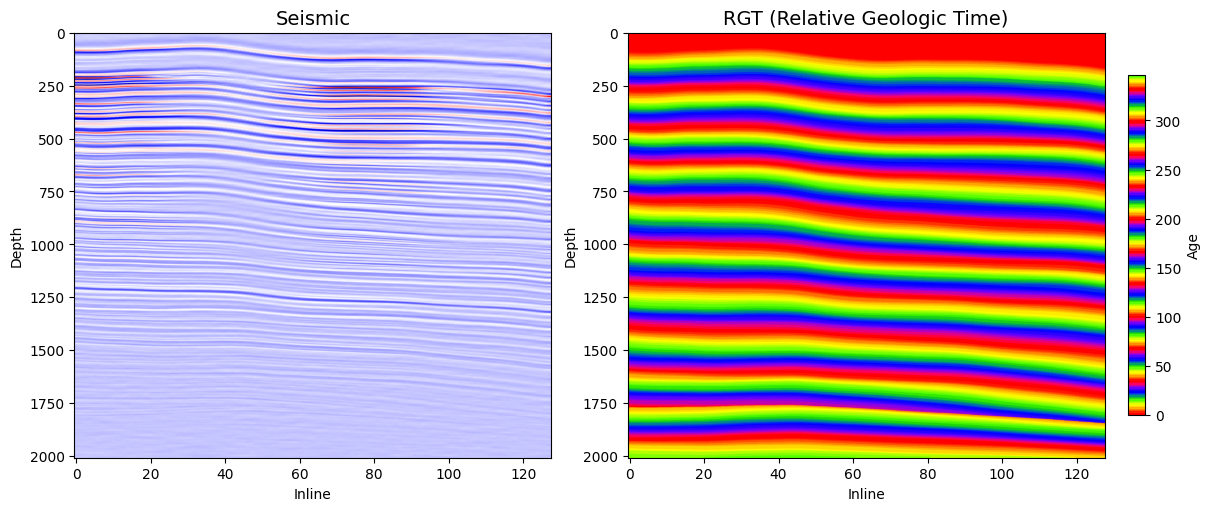

In [8]:
seismic_path = "../data/synthetic_data/run/seismic__2026.25220596_tagilsk_128_128_2000/seismicCubes_cumsum_fullstack_2026.25220596.npy"
rgt_path = "../data/synthetic_data/run/seismic__2026.25220596_tagilsk_128_128_2000/faulted_age_2026.25220596.npy"

seismic = np.load(seismic_path)
rgt = np.load(rgt_path)

slice_idx = 40

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Seismic plot
axes[0].imshow(seismic[slice_idx, :, :].T, cmap='seismic', aspect='auto')
axes[0].set_title('Seismic', fontsize=14)
axes[0].set_xlabel('Inline')
axes[0].set_ylabel('Depth')

# RGT plot
im = axes[1].imshow(rgt[slice_idx, :, :].T, cmap='prism', aspect='auto')
axes[1].set_title('RGT (Relative Geologic Time)', fontsize=14)
axes[1].set_xlabel('Inline')
axes[1].set_ylabel('Depth')

fig.colorbar(im, ax=axes[1], shrink=0.8, label='Age')

plt.show()

In [5]:
cube = "../data/synthetic_data/run/seismic__2026.24319790_tagilsk_2/qc_volume_rho_2026.24319790.npy"
testarr = np.load(cube)
plot_3d_array_interactive(testarr, axis='x')

interactive(children=(IntSlider(value=0, description='X-index:', max=99), Output()), _dom_classes=('widget-int…